## QGAN

In this notebook, we train a PyTorch-based Quantum Generative Adversarial Network with a Qiskit quantum generator to prepare a quantum state close to a given probability distribution.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.optim import Adam
from qiskit import QuantumCircuit
from qiskit.circuit.library import efficient_su2
from qiskit_machine_learning.connectors import TorchConnector
from qiskit_machine_learning.neural_networks import SamplerQNN
from qiskit_machine_learning.primitives import QMLSampler
from qiskit_machine_learning.utils import algorithm_globals
from scipy.stats import entropy

We first generate training data taken from a simple probability distribution

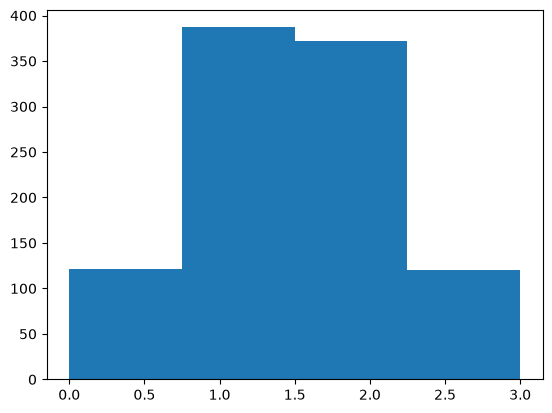

In [2]:
np.random.seed(2020)
N = 1000

real_data = np.random.binomial(3,0.5,N)
plt.hist(real_data, bins = 4);

Now, we define the quantum generator and classical discriminator, train them with the real data, and represent the learned distribution in a histogram.

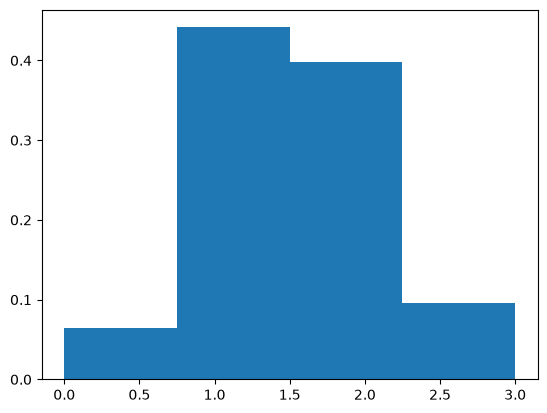

In [3]:
n = 2
num_epochs = 100
num_values = 2**n

algorithm_globals.random_seed = 2020
torch.manual_seed(2020)

target_probabilities = np.bincount(real_data, minlength=num_values) / len(real_data)
samples = torch.arange(num_values, dtype=torch.float32).reshape(-1, 1)

generator_circuit = QuantumCircuit(n)
generator_circuit.h(range(n))
generator_circuit.compose(efficient_su2(n, reps=1, entanglement="linear"), inplace=True)

qnn = SamplerQNN(
    circuit=generator_circuit,
    sampler=QMLSampler(shots=None),
    input_params=[],
    weight_params=generator_circuit.parameters,
    sparse=False,
)
generator = TorchConnector(
    qnn, initial_weights=algorithm_globals.random.random(generator_circuit.num_parameters)
)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(1, 8),
            nn.LeakyReLU(0.2),
            nn.Linear(8, 1),
            nn.Sigmoid(),
        )

    def forward(self, values):
        return self.network(values)

def adversarial_loss(prediction, target, weights):
    prediction = torch.clamp(prediction, 1e-7, 1 - 1e-7)
    return -torch.sum(weights * (target * torch.log(prediction) + (1 - target) * torch.log(1 - prediction)))

discriminator = Discriminator()
generator_optimizer = Adam(generator.parameters(), lr=0.01, betas=(0.7, 0.999), weight_decay=0.005)
discriminator_optimizer = Adam(discriminator.parameters(), lr=0.01, betas=(0.7, 0.999), weight_decay=0.005)

g_loss = []
d_loss = []
rel_entr = []
real_distribution = torch.tensor(target_probabilities, dtype=torch.float32).reshape(-1, 1)
valid = torch.ones(num_values, 1)
fake = torch.zeros(num_values, 1)

for _ in range(num_epochs):
    generated_distribution = generator(torch.tensor([])).reshape(-1, 1)

    generator_optimizer.zero_grad()
    discriminator_values = discriminator(samples)
    generator_loss = adversarial_loss(discriminator_values, valid, generated_distribution)
    generator_loss.backward()
    generator_optimizer.step()

    discriminator_optimizer.zero_grad()
    discriminator_values = discriminator(samples)
    real_loss = adversarial_loss(discriminator_values, valid, real_distribution)
    fake_loss = adversarial_loss(discriminator_values, fake, generated_distribution.detach())
    discriminator_loss = (real_loss + fake_loss) / 2
    discriminator_loss.backward()
    discriminator_optimizer.step()

    g_loss.append(generator_loss.item())
    d_loss.append(discriminator_loss.item())
    rel_entr.append(entropy(generated_distribution.detach().squeeze().numpy(), target_probabilities))

with torch.no_grad():
    prob_g = generator().numpy()

plt.hist(range(num_values), weights=prob_g, bins=num_values);

We show the evolution of the loss function of both the generator and the discriminator

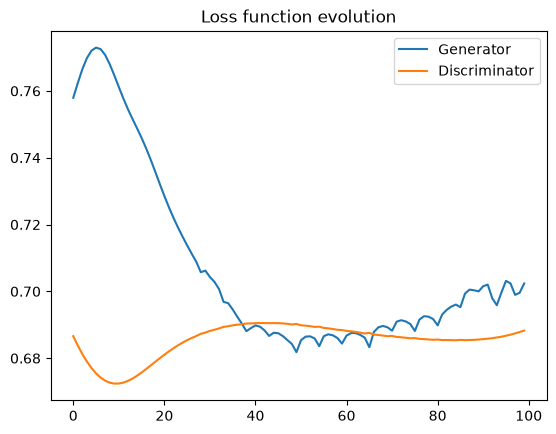

In [4]:
plt.title("Loss function evolution")
plt.plot(range(num_epochs), g_loss, label='Generator')
plt.plot(range(num_epochs), d_loss, label='Discriminator')
plt.legend()
plt.show()

And, also, the evolution of the relative entropy during the training.

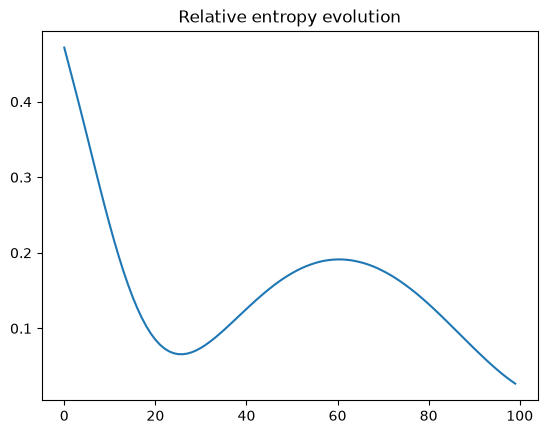

In [5]:
plt.title('Relative entropy evolution')
plt.plot(rel_entr)
plt.show()

In [ ]:
from importlib.metadata import version

print("Qiskit:", version("qiskit"))
print("Qiskit Machine Learning:", version("qiskit-machine-learning"))
print("PyTorch:", version("torch"))